# Filling Gaps with model results

In the previous tutorial, we learnt to fill gaps left by monitoring stations using satellite images. Another alternative to satellite images is model results.

Scientists use satellite data, monitoring data, emissions inventories, machine learning and atmospheric modeling to produce estimates on what could be a pollutant's concentration in any given grid. A grid is nothing but a square pixel on ground.

In this tutorial we will use a [model output](https://zenodo.org/records/17975718) produced by researchers at the [Centre for Research on Energy and Clean Air (CREA)](https://energyandcleanair.org/). 

## Understanding the model outputs

This [model output](https://zenodo.org/records/17975718) estimated the concentration of PM2.5 (μg/m3) every day from 2018-08-01 to 2025-09-30* at 10 km resolution for India.

A 10km resolution is large as each pixel will be of size 100 sq.km. Advanced models can give estimate a pollutant's concentration in even small grids of resolution 1km, but they would be of larger size.

*_as on March 12th, 2026 when this tutorial is written_

The [model output](https://zenodo.org/records/17975718) is available to download in the form of `NetCDF` file. This is standard format in which a lot of modeling results are shared by the scientific community. We can work with `NetCDF` files using `xarray` library on python.

In this tutorial, we will download the [pm25-full_rel-2025-11-r0_s-1.0_mb-1.0-r0.nc](https://zenodo.org/records/17975718/files/pm25-full_rel-2025-11-r0_s-1.0_mb-1.0-r0.nc?download=1) and work with it. It is ~300MB in size. We will crop out the grids from Delhi and see the `pm2.5` pollution in Delhi.

In [44]:
import xarray as xr
import geopandas as gpd

In [47]:
# Open the downloaded NetCDF file
ds = xr.open_dataset('data/pm25-full_rel-2025-11-r0_s-1.0_mb-1.0-r0.nc', chunks={})
ds

<xarray.Dataset> Size: 986MB
Dimensions:      (time: 2618, y: 328, x: 287)
Coordinates:
  * time         (time) datetime64[ns] 21kB 2018-08-01 2018-08-02 ... 2025-09-30
  * y            (y) float32 1kB 2.176e+06 2.186e+06 ... 5.436e+06 5.446e+06
  * x            (x) float32 1kB 2.816e+06 2.826e+06 ... 5.666e+06 5.676e+06
Data variables:
    pm25         (time, y, x) float32 986MB dask.array<chunksize=(16, 82, 72), meta=np.ndarray>
    spatial_ref  int64 8B ...
Attributes:
    Conventions:   CF-1.8
    GeoTransform:  2811163.0 10000.0 0.0 2181392.0 0.0 -10000.0

Lets take sometime to understand the `NetCDF` file. We can read that this file has two variables `pm25` and `spatial_ref`. The `pm25` variable is what we are interested in. We can also see that there are `time`, `x` and `y` co-ordinates. The `time` is from `2018-08-01` to `2025-09-30`. `x` and `y` are longitudes and latitudes of the centre of each pixel. But the `NetCDF` is using a [co-ordinate reference system (CRS)](https://docs.qgis.org/3.40/en/docs/gentle_gis_introduction/coordinate_reference_systems.html) of `EPSG: 7755` and hence it has such large values.

We can look at the `pm25` Data Array to get a better sense of how the data is organised:

In [53]:
ds['pm25']

<xarray.DataArray 'pm25' (time: 2618, y: 328, x: 287)> Size: 986MB
dask.array<open_dataset-pm25, shape=(2618, 328, 287), dtype=float32, chunksize=(16, 82, 72), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 21kB 2018-08-01 2018-08-02 ... 2025-09-30
  * y            (y) float32 1kB 2.176e+06 2.186e+06 ... 5.436e+06 5.446e+06
  * x            (x) float32 1kB 2.816e+06 2.826e+06 ... 5.666e+06 5.676e+06
    spatial_ref  int64 8B 0

The `pm25` data is organised in the form of a 3-dimensional matrix. The `x` and `y` map the surface of India. Each deeper layer is one matrix giving us the `pm25` concentration data of a single day.

## Cropping the model results to geography of Interest

The above modeling result is for all India. In this tutorial, we are only interested to know the `pm2.5` levels in Delhi.

In [66]:
delhi_districts = gpd.read_file('data/DELHI_DISTRICTS.geojson')

In [67]:
# We assign the CRS explicitly
ds = ds.rio.set_spatial_dims(x_dim="x", y_dim="y")
ds = ds.rio.write_crs("EPSG:7755")

In [68]:
# Ensure that both Delhi file and Netcdf file has same CRS
delhi_districts = delhi_districts.to_crs(ds.rio.crs)

In [69]:
# Get the bounding box coordinates of Delhi
minx, miny, maxx, maxy = delhi_districts.total_bounds

clipped = ds.rio.clip_box(
    minx=minx,
    miny=miny,
    maxx=maxx,
    maxy=maxy
)

In [70]:
clipped['pm25']

<xarray.DataArray 'pm25' (time: 2618, y: 6, x: 6)> Size: 377kB
dask.array<getitem, shape=(2618, 6, 6), dtype=float32, chunksize=(16, 6, 6), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 21kB 2018-08-01 2018-08-02 ... 2025-09-30
  * y            (y) float32 24B 4.486e+06 4.496e+06 ... 4.526e+06 4.536e+06
  * x            (x) float32 24B 3.696e+06 3.706e+06 ... 3.736e+06 3.746e+06
    spatial_ref  int64 8B 0

We can see that the number of `x` and `y` reduced, but number of `time` did not reduce. This is because we cropped the `NetCDF` to Delhi region. But we didn't select the days on which want the data for. We can just treat this as a 3-dimensional matrix and select the day we want using index. To select the last date, i.e., `2025-09-30`, we can either  use index `-1` or `2617`

In [58]:
pm25_20250930 = clipped["pm25"][-1,:,:]
#pm25_20250930 = clipped["pm25"].isel(time=-1)
pm25_20250930

<xarray.DataArray 'pm25' (y: 6, x: 6)> Size: 144B
dask.array<getitem, shape=(6, 6), dtype=float32, chunksize=(6, 6), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 24B 4.486e+06 4.496e+06 ... 4.526e+06 4.536e+06
  * x            (x) float32 24B 3.696e+06 3.706e+06 ... 3.736e+06 3.746e+06
    time         datetime64[ns] 8B 2025-09-30
    spatial_ref  int64 8B 0

## Plotting the model results for Delhi

The DataArray can be easily visualised using the `.plot()` function.

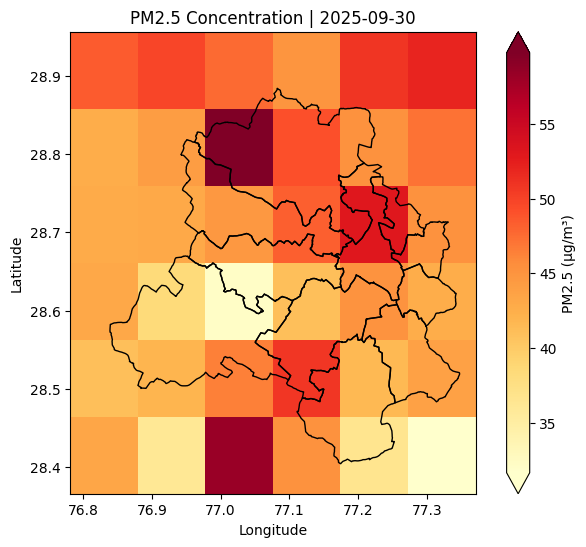

In [89]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(8,6))

# plot pm2.5 raster
pm25_20250930.rio.reproject("EPSG:4326").plot(
    ax=ax,
    cmap="YlOrRd",
    robust=True,
    cbar_kwargs={"label": "PM2.5 (µg/m³)"}
)

# overlay boundary
delhi_districts.to_crs("EPSG:4326").boundary.plot(
    ax=ax,
    color="black",
    linewidth=1
)

# labels and title
ax.set_title("PM2.5 Concentration | 2025-09-30")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

plt.show()

We can also save this matrix as a `TIF` file and plot it in the same way we [plotted satellite images](https://urbanemissionsinfo.github.io/AirQualityVisuals/notebooks/Plotting_SatelliteImages.html).

In [90]:
# Write the GeoTIFF
pm25_20250930.rio.to_raster('pm25_20250930.tif')

## Analysis with model results

### Which grid in India has met Air Quality Standards in 2024?

We can also do more analysis with such modeling results.

For example, we want to know which 10x10km grid in India has met the [Air Quality Standards](https://urbanemissionsinfo.github.io/AQCourse/notebooks/Air_Quality_Standards.html) for `PM2.5` pollutant, in the year 2024.

To know this, we can take a mean of pm25 variable for all days in the year 2024, for each grid. Then we can see which grid meets the standard. 

In [125]:
# select matrices of all days in 2024 - chosen by selecting appropriate index
pm25_2024 = ds['pm25'][1979:1979+366,:,:]
pm25_2024

<xarray.DataArray 'pm25' (time: 366, y: 328, x: 287)> Size: 138MB
dask.array<getitem, shape=(366, 328, 287), dtype=float32, chunksize=(16, 82, 72), chunktype=numpy.ndarray>
Coordinates:
  * time         (time) datetime64[ns] 3kB 2024-01-01 2024-01-02 ... 2024-12-31
  * y            (y) float32 1kB 2.176e+06 2.186e+06 ... 5.436e+06 5.446e+06
  * x            (x) float32 1kB 2.816e+06 2.826e+06 ... 5.666e+06 5.676e+06
    spatial_ref  int64 8B 0

In [126]:
# Calculate mean
pm25_mean = pm25_2024.mean(dim="time")
pm25_mean

<xarray.DataArray 'pm25' (y: 328, x: 287)> Size: 377kB
dask.array<mean_agg-aggregate, shape=(328, 287), dtype=float32, chunksize=(82, 72), chunktype=numpy.ndarray>
Coordinates:
  * y            (y) float32 1kB 2.176e+06 2.186e+06 ... 5.436e+06 5.446e+06
  * x            (x) float32 1kB 2.816e+06 2.826e+06 ... 5.666e+06 5.676e+06
    spatial_ref  int64 8B 0

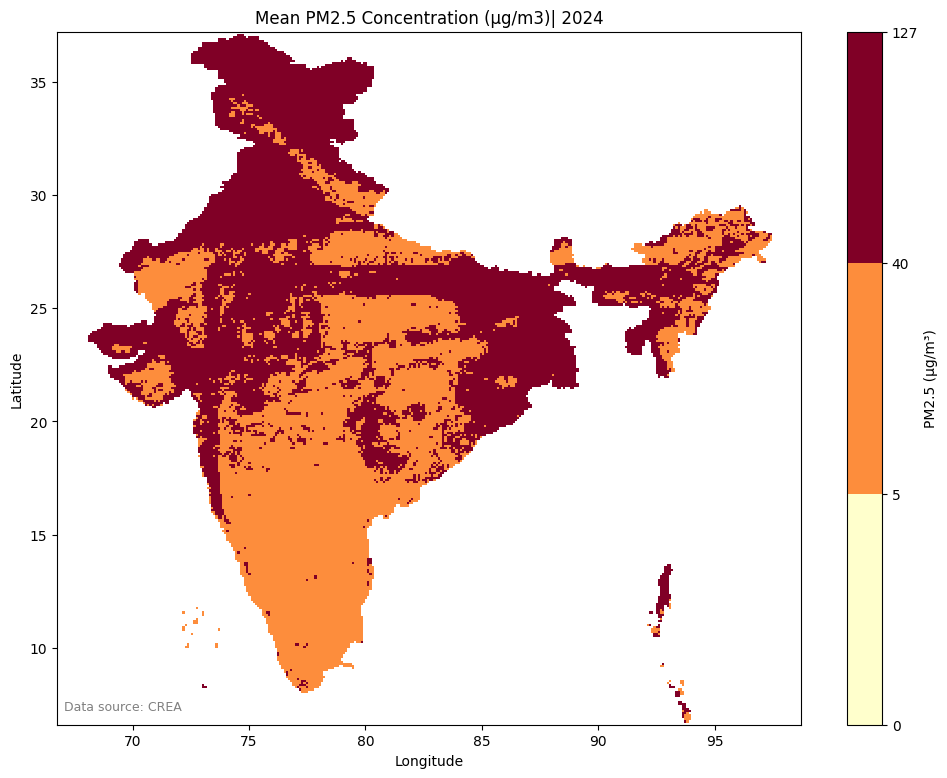

In [138]:
#Plot the mean with required color mapping

# define class breaks
max_val = pm25_mean.max().compute().item()
bounds = [0, 5, 40, round(max_val)] #WHO Standard, NAAQS

# choose 3 colors from YlOrRd
cmap = plt.get_cmap("YlOrRd", 3)
norm = mcolors.BoundaryNorm(bounds, cmap.N)


# plot pm2.5 raster
fig, ax = plt.subplots(figsize=(12,9))
pm25_mean.rio.reproject("EPSG:4326").plot(
    ax=ax,
    cmap=cmap,
    norm=norm,
    cbar_kwargs={
        "label": "PM2.5 (µg/m³)",
        "ticks": bounds
    }
)

# labels and title
ax.set_title("Mean PM2.5 Concentration (μg/m3)| 2024")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

# data source annotation
ax.text(
    0.01, 0.02,
    "Data source: CREA",
    transform=ax.transAxes,
    fontsize=9,
    color="gray"
)
plt.savefig('pm25mean_india_2024.png')
plt.show()

In [139]:
pm25_mean.min().compute().item()

13.391748428344727

As per this modeling result, there is no 10x10km grid in India that met W.H.O guideline of 5 μg/m3, in 2024.

## Summary

In this tutorial, we learnt about model outputs and how to work with `NetCDF` files. We learnt to crop and plot model results to a geography of interest. We also learnt how we can analyse model results to ask various research and policy questions. 